In [31]:
#!pip install seaborn
#!pip install scipy

In [32]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## Phần 1 - Thống kê mô tả & đặc trưng

In [33]:
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


Có 150 dòng và 5 cột lần lượt là: 
- sepal_length: float64
- sepal_width: float64
- petal_length: float64
- petal_width: float64
- species: str

In [34]:
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    mean = df[column].mean()
    median = df[column].median()
    mode = df[column].mode()[0]
    var = df[column].var()
    std = df[column].std()
    min_value = df[column].min()
    max_value = df[column].max()
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    print(f"{column}:")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Variance: {var}")
    print(f"Standard Deviation: {std}")
    print(f"Min: {min_value}")
    print(f"Max: {max_value}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}\n")

sepal_length:
Mean: 5.843333333333334
Median: 5.8
Mode: 5.0
Variance: 0.6856935123042507
Standard Deviation: 0.828066127977863
Min: 4.3
Max: 7.9
Q1: 5.1
Q3: 6.4
IQR: 1.3000000000000007

sepal_width:
Mean: 3.0573333333333337
Median: 3.0
Mode: 3.0
Variance: 0.189979418344519
Standard Deviation: 0.4358662849366982
Min: 2.0
Max: 4.4
Q1: 2.8
Q3: 3.3
IQR: 0.5

petal_length:
Mean: 3.7580000000000005
Median: 4.35
Mode: 1.4
Variance: 3.116277852348993
Standard Deviation: 1.7652982332594662
Min: 1.0
Max: 6.9
Q1: 1.6
Q3: 5.1
IQR: 3.4999999999999996

petal_width:
Mean: 1.1993333333333336
Median: 1.3
Mode: 0.2
Variance: 0.5810062639821029
Standard Deviation: 0.7622376689603465
Min: 0.1
Max: 2.5
Q1: 0.3
Q3: 1.8
IQR: 1.5



| Chỉ số thống kê | Sepal Length | Sepal Width | Petal Length | Petal Width |
| :--- | :---: | :---: | :---: | :---: |
| **Mean (Trung bình)** | 5.84 | 3.06 | 3.76 | 1.20 |
| **Median (Trung vị)** | 5.80 | 3.00 | 4.35 | 1.30 |
| **Mode (Yếu vị)** | 5.00 | 3.00 | 1.40 | 0.20 |
| **Variance (Phương sai)** | 0.69 | 0.19 | 3.12 | 0.58 |
| **Std Deviation (Độ lệch chuẩn)** | 0.83 | 0.44 | 1.77 | 0.76 |
| **Min (Tối thiểu)** | 4.30 | 2.00 | 1.00 | 0.10 |
| **Max (Tối đa)** | 7.90 | 4.40 | 6.90 | 2.50 |
| **Q1 (Tứ phân vị 25%)** | 5.10 | 2.80 | 1.60 | 0.30 |
| **Q3 (Tứ phân vị 75%)** | 6.40 | 3.30 | 5.10 | 1.80 |
| **IQR (Khoảng biến thiên tứ phân vị)**| 1.30 | 0.50 | 3.50 | 1.50 |


> **Nhận xét:** 
Thuộc tính `petal_length` có độ lệch chuẩn (`1.77`) và khoảng biến thiên tứ phân vị (`3.5`) lớn nhất, cho thấy kích thước chiều dài cánh hoa có sự phân hóa rất mạnh giữa các loài hoa Iris.
Ngược lại, `sepal_width` (chiều rộng đài hoa) là thuộc tính ổn định và ít thay đổi nhất với độ lệch chuẩn chỉ `0.44`.

In [35]:
df.groupby('species').agg(['mean','std'])

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

> **Nhận xét:**

- Về Cánh hoa (petal): Chiều dài cánh hoa (petal_length) của `setosa` chỉ có giá trị trung bình là `1.462 cm` và độ lệch chuẩn nhỏ gần bằng `0.17`, so với giá trị trung bình của `versicolor` là `4.260` cm và `virginica` là `5.552` cm. Chiều rộng cánh hoa (petal_width): `setosa` có kích thước siêu nhỏ với trung bình là `0.246` cm, trong khi đó hai loài còn lại có giá trị trung bình lớn hơn hẳn lần lượt là `1.326` cm và  `2.026` cm.

- Về Đài hoa (sepal): `setosa` là loài duy nhất có đài hoa thiên hướng hình cầu dẹt. Chiều rộng đài hoa trung bình của nó đạt `3.428` cm (lớn nhất trong 3 loài), trong khi chiều dài đài hoa lại ngắn nhất (`5.006` cm). Ngược lại, hai loài `versicolor` và `virginica` có xu hướng đài hoa thon dài hơn (độ rộng chỉ vào khoảng `2.7`-`2.9` cm).

## Phần 2 - Phân phối xác suất

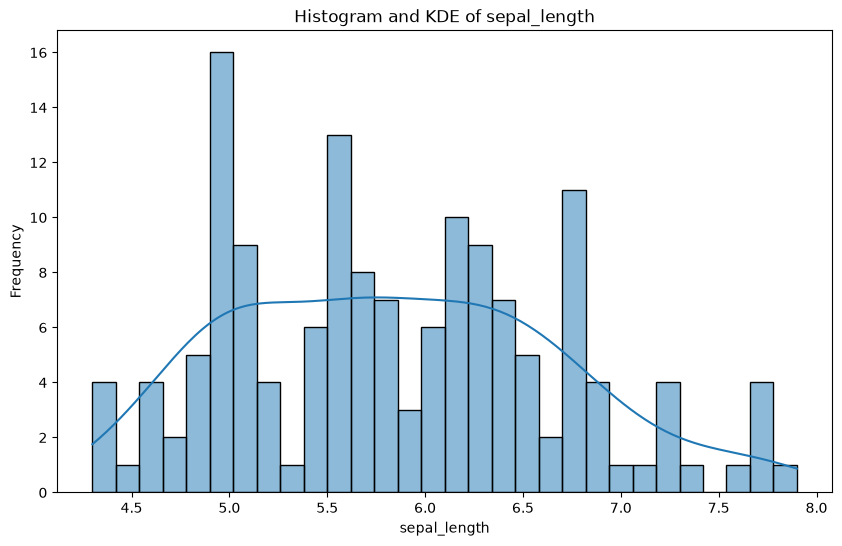

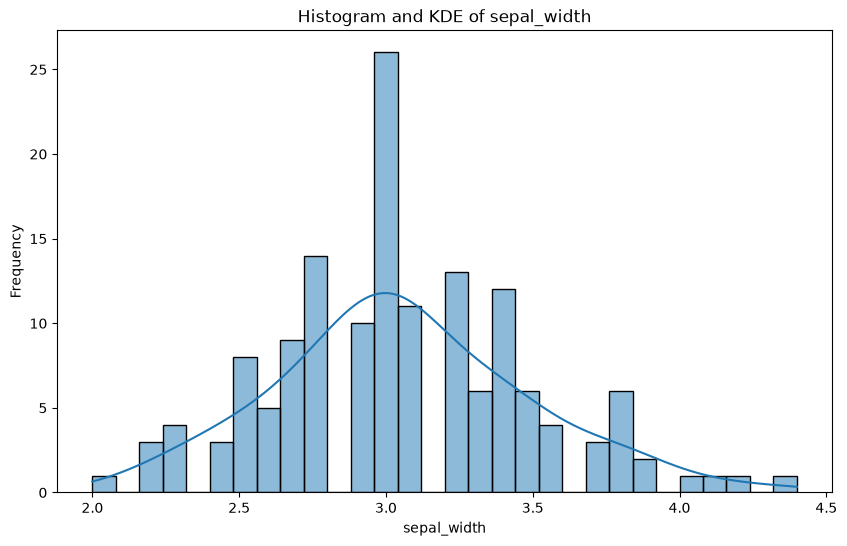

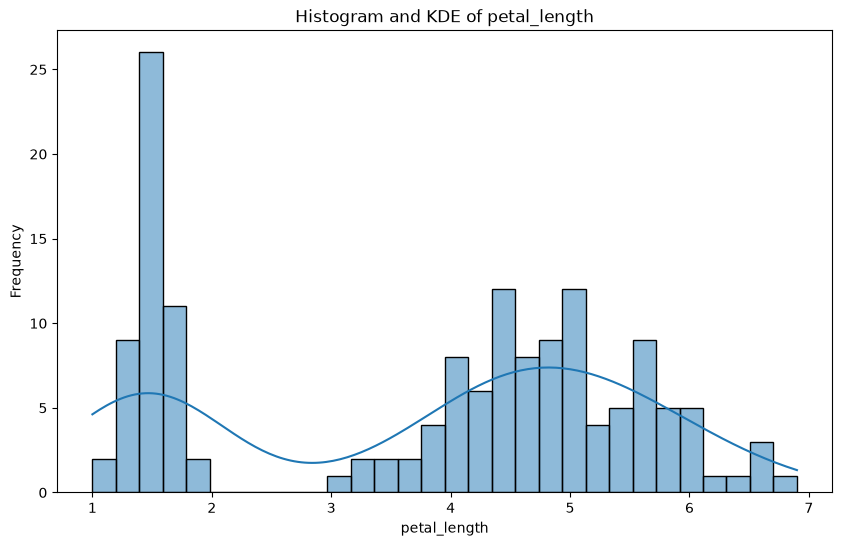

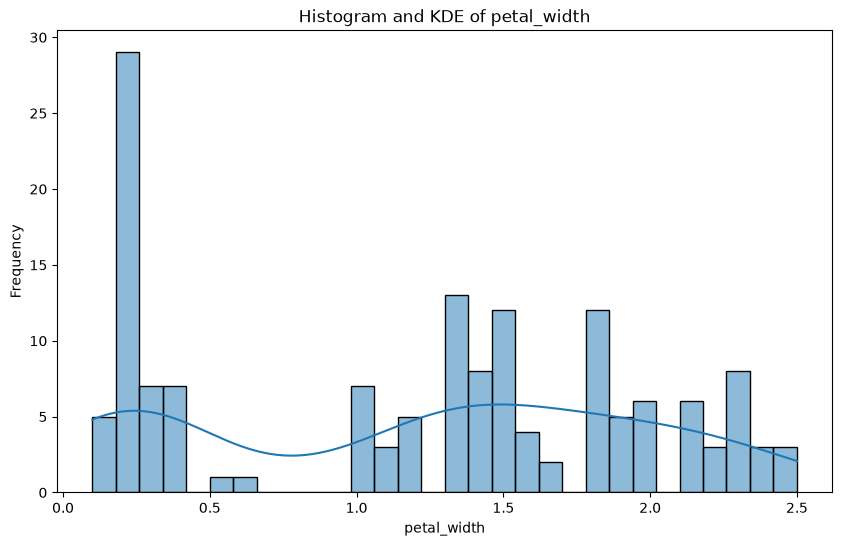

In [36]:
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Histogram and KDE of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()




> **Nhận xét:**
- `sepal_length`: Hình dạng phân phối nhiều đỉnh, có 4 cụm đỉnh nổi trội gồm cụm quanh giá trị 5.0, cụm quanh 5.5-5.7, cụm quanh 6.2 và cụm quanh 6.8
- `sepal_width`: Hình dạng phân phối gần phân phối chuẩn. Dữ liệu tập trung cao nhất ở khu vực trung tâm (quanh giá trị 3.0) và giảm dần đều về 2 bên.
- `petal_length`: Hình dạng phân phối nhiều đỉnh và bị phân tách thành 2 cụm. Cụm thứ nhất (bên trái): Tập trung rất cao và hẹp quanh giá trị từ 1.0 đến 2.0, tạo thành một đỉnh nhọn, cao hẳn lên. Cụm thứ hai (bên phải): Trải rộng từ khoảng 3.0 đến 7.0, có dạng phân phối gần phân phối chuẩn.
- `petal_width`: Hình dạng phân phối có nhiều đỉnh và bị phân tách thành 2 cụm. Cụm thứ nhất (bên trái) tập trung rất cao và hẹp ở khoảng giá trị nhỏ từ 0.1 đến khoảng 0.6, tạo thành một đỉnh nhọn, đứng cô lập. Trải dài từ khoảng 1.0 đến 2.5. Trong cụm lớn này lại trồi sụt thành nhiều đỉnh nhỏ khác nhau (quanh các mốc 1.3, 1.8 và 2.3). 

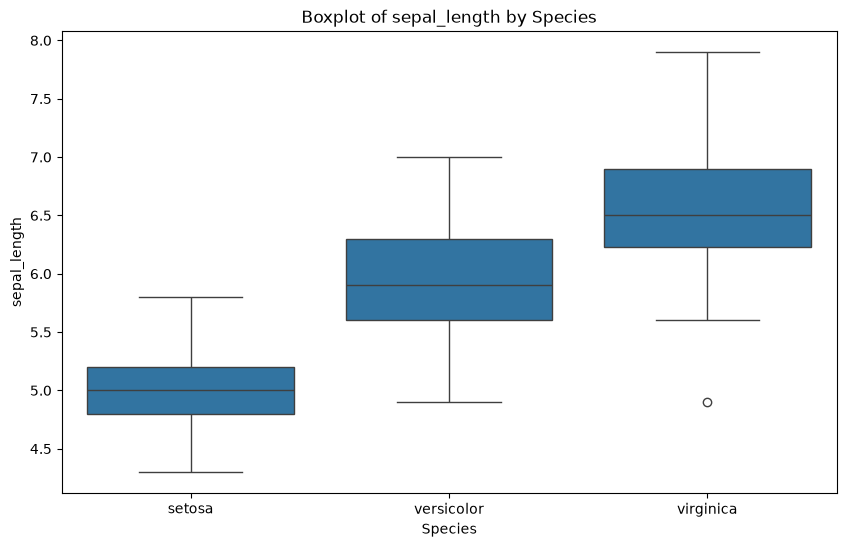

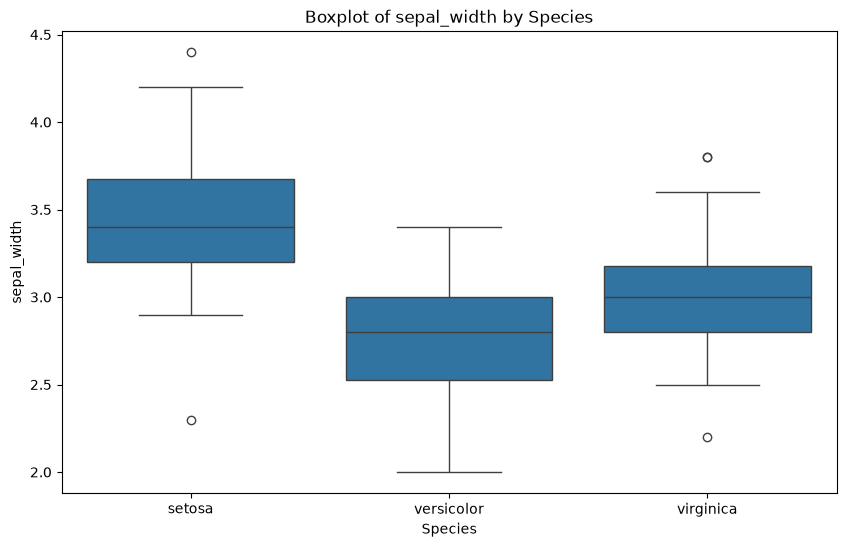

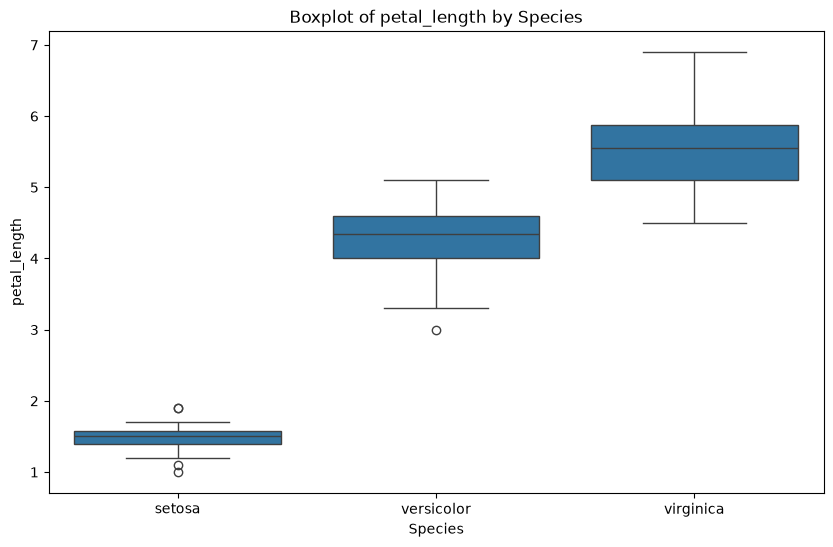

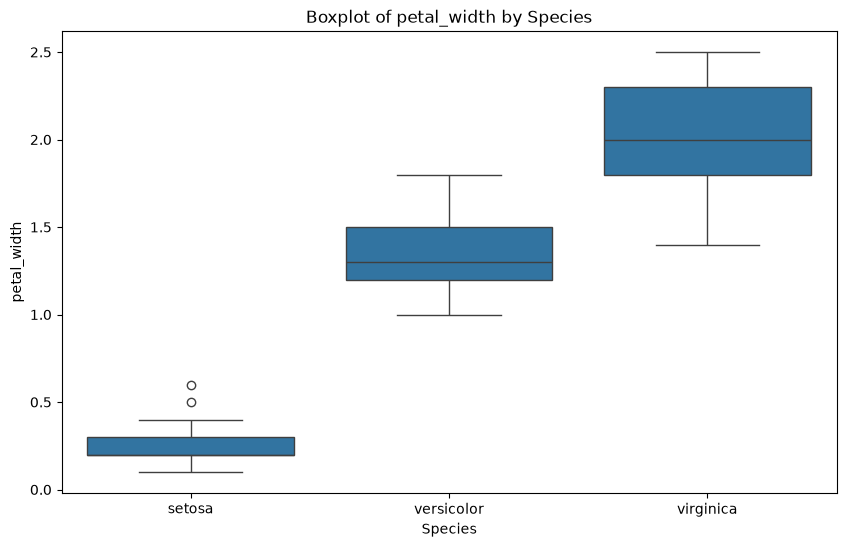

In [37]:
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='species', y=column, data=df)
    plt.title(f'Boxplot of {column} by Species')
    plt.xlabel('Species')
    plt.ylabel(column)
    plt.show()


> **Nhận xét:**
- `sepal_length`: 
  - Có sự tăng dần rõ rệt về chiều dài lá đài giữa các loài. Loài `setosa` có trung vị thấp nhất (5.006 cm), tiếp theo là `versicolor` (5.936 cm), và loài `virginica` có trung vị lớn nhất (6.588 cm).
  - Loài `setosa` có kích thước lá đài đồng đều và ít biến động nhất, dao động chủ yếu từ 4.3 đến 5.8 cm. Loài `versicolor` và `virginica` có độ phân tán dữ liệu rộng hơn đáng kể, cho thấy kích thước lá đài của hai loài này biến thiên nhiều hơn.
  - Loài `setosa` tách biệt khá rõ ràng, hầu như không chồng lấp hoặc chỉ chồng lấp rất ít phần rìa trên với phần rìa dưới của `versicolor`. Ngược lại, giữa `versicolor` và `virginica` có một khoảng chồng lấp khá lớn (vùng từ 5.6 đến 7.0 cm), cho thấy nếu chỉ dựa vào chiều dài lá đài thì khó phân biệt hoàn toàn hai loài này.
  - Loài `virginica` xuất hiện một điểm dị biệt (outlier) nằm hẳn phía dưới (khoảng 4.9 cm)

- `sepal_width`:
  - Loài `setosa` có độ rộng lá đài lớn nhất với trung vị 3.428 cm. Tiếp theo là loài `virginica` với trung vị ở mức 2.770 cm. Loài `versicolor` có độ rộng lá đài nhỏ nhất với giá trị trung vị khoảng 2.974 cm. 
  - Khoảng biến thiên tứ phân vị (IQR) của ba loài có độ lớn khá tương đương nhau, cho thấy mức độ phân tán dữ liệu ở vùng trung tâm của mỗi loài không quá chênh lệch
  - Loài `setosa` nổi trội hẳn với lá đài bản rộng, trong khi hai loài `versicolor` và `virginica` có kích thước lá đài nhỏ hơn và có một khoảng giao thoa dữ liệu khá lớn với nhau.
  - Loài `setosa` xuất hiện 2 điểm ngoại lai (một điểm rất cao khoảng 4.4 cm và một điểm rất thấp khoảng 2.3 cm).
  - Loài `virginica` cũng xuất hiện 2 điểm ngoại lai (một điểm cao khoảng 3.8 cm và một điểm thấp khoảng 2.2 cm).

- `petal_length`: 
  - Có sự phân cấp tăng dần cực kỳ rõ ràng giữa các loài. Loài `setosa` có chiều dài cánh hoa ngắn nhất (trung vị 1.462 cm). Loài `versicolor` đứng ở vị trí trung bình (trung vị 4.260 cm). Loài `virginica` có chiều dài cánh hoa lớn nhất (trung vị 5.552 cm).
  - Hộp của loài `setosa` rất hẹp, cho thấy dữ liệu cực kỳ đồng đều và tập trung cao độ ở khoảng kích thước nhỏ. Đặc biệt, hộp của `setosa` hoàn toàn tách biệt, không hề chồng lấn với hai loài còn lại.
  - Loài `versicolor` và `virginica` có độ phân tán dữ liệu rộng hơn (IQR lớn hơn). Tuy có sự phân cấp rõ ràng về trung vị nhưng giữa hai loài này vẫn có một chút giao thoa nhẹ ở vùng rìa (khoảng từ 4.5 cm đến 5.1 cm).
  - Loài `setosa` xuất hiện một vài điểm ngoại lai ở cả phía trên (gần 2.0 cm) và phía dưới (quanh mức 1.0 cm).
  - Loài `versicolor` xuất hiện 1 điểm ngoại lai thấp bất thường ở mức 3.0 cm.
  
- `petal_width`:
  - Tương tự như chiều dài cánh hoa, độ rộng cánh hoa cũng có sự phân cấp tăng dần vô cùng rõ ràng. Loài `setosa` có cánh hoa mảnh nhất (trung vị 0.246 cm). Loài `versicolor` ở mức trung bình (trung vị 1.326 cm). Loài `virginica` có cánh hoa dày/rộng nhất (trung vị 2.026 cm).
  - Hộp của loài `setosa` cực kỳ hẹp và nằm sát đáy biểu đồ. Loài `versicolor` và `virginica` có hộp dữ liệu rộng hơn (độ biến thiên lớn hơn). Giữa hai loài này hầu như không chồng lấn phần hộp chính (IQR), chỉ có một chút giao thoa rất nhẹ ở vùng râu (khoảng 1.4 cm).
  - Loài `setosa` xuất hiện 2 điểm ngoại lai lớn bất thường ở phía trên (khoảng 0.5 cm và 0.6 cm).


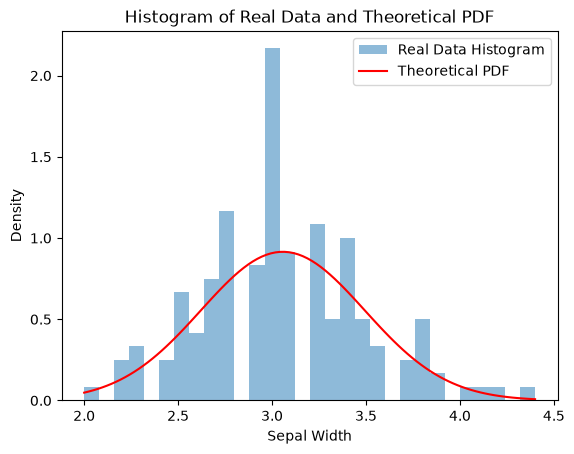

In [38]:
real_data = df['sepal_width']
mean = real_data.mean()
std = real_data.std()

plt.hist(real_data, bins=30, density=True, alpha=0.5, label='Real Data Histogram')

x = np.linspace(real_data.min(), real_data.max(), 100)
pdf = stats.norm.pdf(x, mean, std)
plt.plot(x, pdf, 'r-', label='Theoretical PDF')
plt.title('Histogram of Real Data and Theoretical PDF')
plt.xlabel('Sepal Width')
plt.ylabel('Density')
plt.legend()
plt.show()


> **Nhận xét:**
Nhìn chung, mức độ khớp giữa dữ liệu thực tế và mô hình lý thuyết ở mức khá cao. Biểu đồ histogram phản ánh rõ nét cấu trúc đối xứng đặc trưng của phân phối chuẩn, với mật độ dữ liệu tập trung lớn nhất tại khu vực trung tâm và giảm dần đều về hai phía biên. Sai lệch đáng kể nhất chỉ xuất hiện cục bộ tại giá trị quanh mốc 3.0, nơi dữ liệu thực tế tập trung dày đặc ngoài dự kiến khiến cột tần suất nhô cao vượt trội so với đỉnh của đường PDF.

## Phần 3 - Phân tích đa biến & tương quan

In [ ]:
numerical_columns = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
cov_matrix = numerical_columns.cov()
print("Covariance Matrix:")
print(cov_matrix)

corr_matrix = numerical_columns.corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

Covariance Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


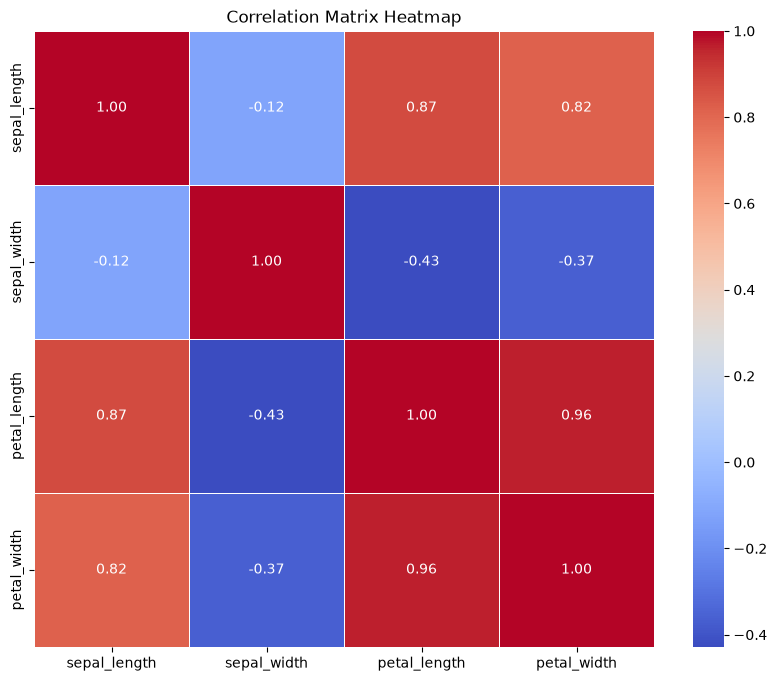

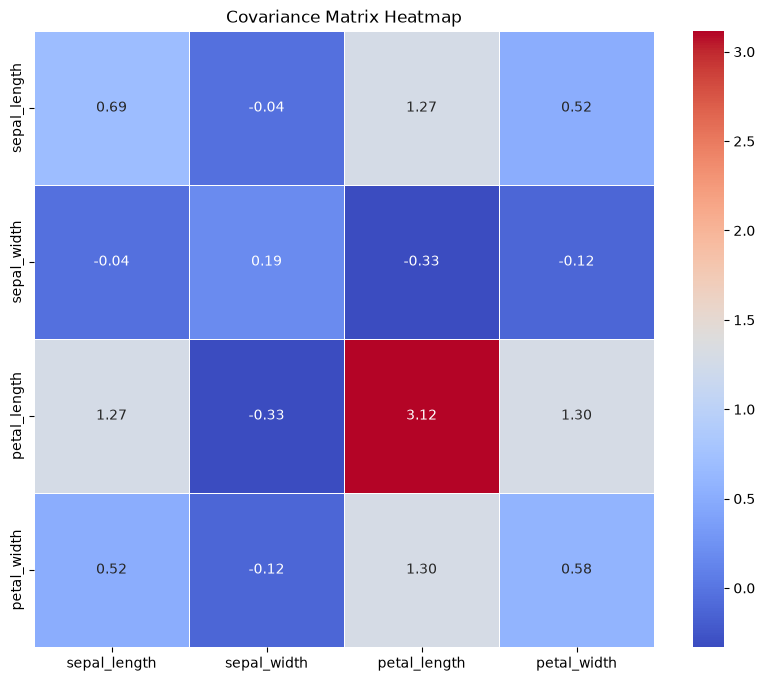

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Covariance Matrix Heatmap')
plt.show()

> **Nhận xét:**
- Cặp biến có mối tương quan tuyến tính mạnh nhất là petal_length (chiều dài cánh hoa) và petal_width (độ rộng cánh hoa) với hệ số tương quan đạt tới $r \approx 0.96$
- Các cặp biến như sepal_length với petal_length ($r \approx 0.87$) và sepal_length với petal_width ($r \approx 0.82$) cũng thể hiện mối tương quan thuận rất mạnh.

> **Kết luận:** Tập dữ liệu có dấu hiệu đa cộng tuyến rất rõ rệt. 

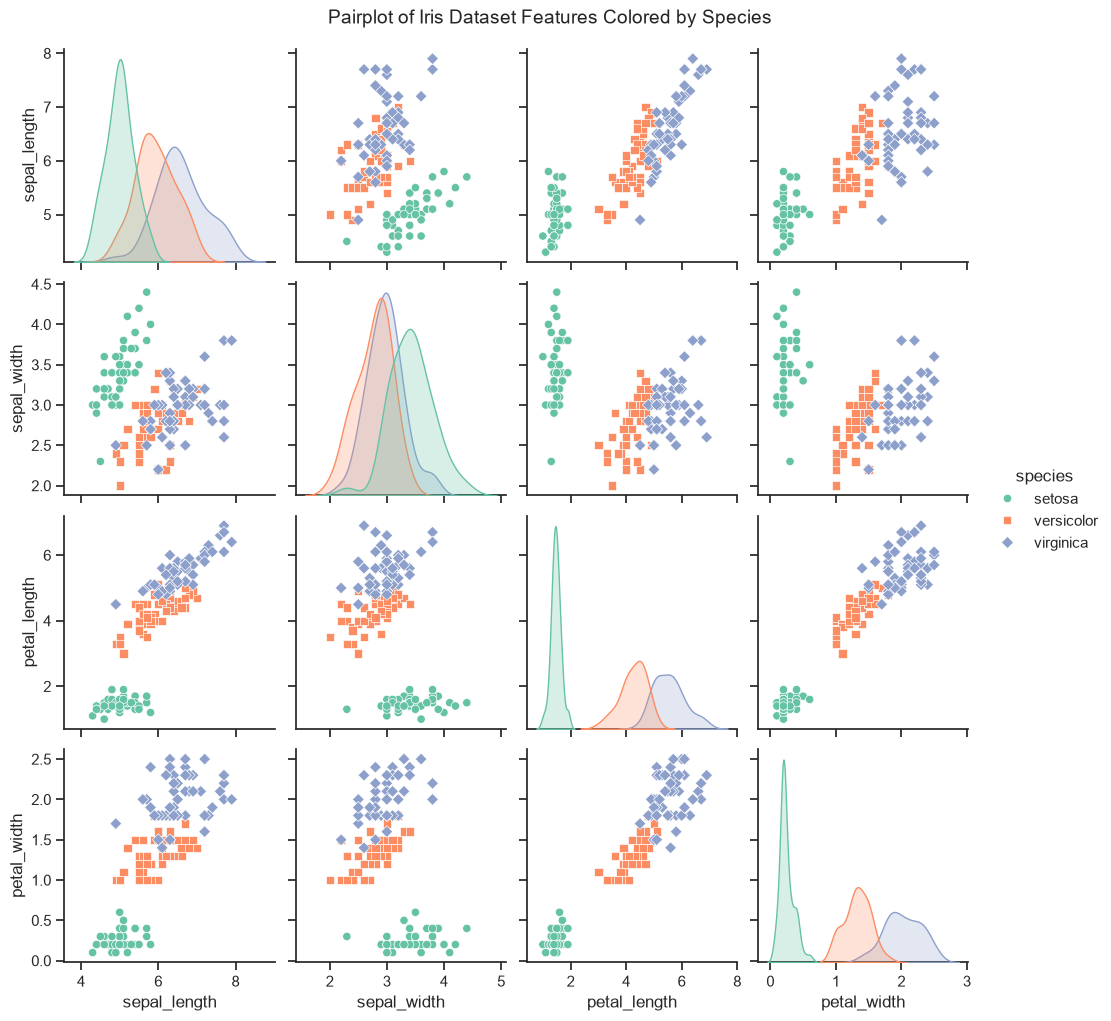

In [46]:
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde', markers=["o", "s", "D"])
pair_plot.fig.suptitle("Pairplot of Iris Dataset Features Colored by Species", y=1.02, fontsize=14)

plt.show()

> **Nhận xét**: 
- Loài `setosa` luôn đứng cô lập thành một cụm hoàn toàn riêng biệt trên mọi ô đồ thị phân tán liên quan đến cánh hoa (`petal_length` và `petal_width`). Trên đường chéo chính (KDE), đường mật độ của `setosa` cũng tách rời 100% khỏi hai loài còn lại. Điều này chứng tỏ kích thước cánh hoa là đặc trưng vàng, giúp nhận diện loài `setosa` mà không sợ bị nhầm lẫn.
- Dữ liệu của hai loài `versicolor` và `virginica` này có xu hướng nối đuôi nhau và đan xen (overlap) một phần ở vùng ranh giới. Loài `virginica` nhìn chung luôn có kích thước lớn hơn loài `versicolor` ở các đặc trưng `sepal_length`, `petal_length` và `petal_width`.

## Phần 4 — Xác suất & Định lý Bayes

In [47]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos = (P_pos_givenB * P_B) + (P_pos_givenNB * (1 - P_B))
P_B_given_pos = (P_pos_givenB * P_B) / P_pos
print(f"P(B|pos) = {P_B_given_pos:.4f}")

P(B|pos) = 0.1667


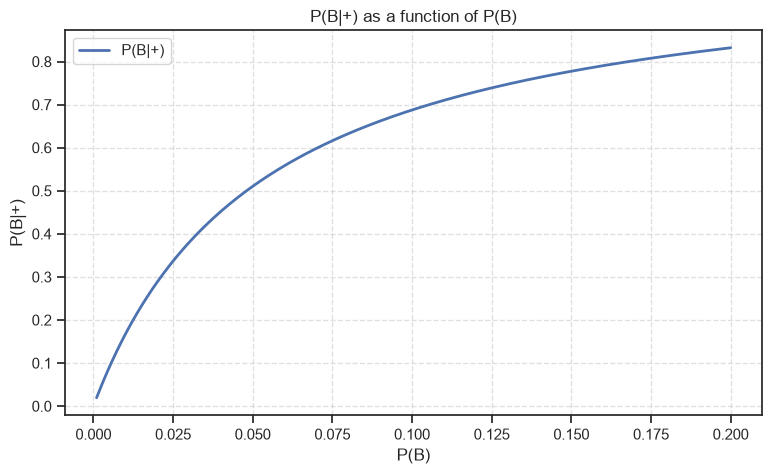

In [52]:
P_B_values = np.linspace(0.001, 0.2, 500)
P_NB_values = 1 - P_B_values
P_pos_values = (P_pos_givenB * P_B_values) + (P_pos_givenNB * P_NB_values)
P_B_given_pos_values = (P_pos_givenB * P_B_values) / P_pos_values

plt.figure(figsize=(9, 5))
plt.plot(P_B_values, P_B_given_pos_values, 'b-', lw = 2, label='P(B|+)')

plt.title('P(B|+) as a function of P(B)')
plt.xlabel('P(B)')
plt.ylabel('P(B|+)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

> **Nhận xét:** Kết quả này "phản trực giác" là do hiện tượng "Ngụy biện về tỷ lệ nền" (Base Rate Fallacy). Khi một căn bệnh quá hiếm trong cộng đồng ($P(B) = 0.01$), quy mô quần thể người khỏe mạnh sẽ cực kỳ lớn ($99\%$).  Dù xét nghiệm có tỷ lệ dương tính giả rất thấp ($5\%$), nhưng khi áp vào nhóm người khỏe mạnh này, nó vẫn tạo ra số lượng ca bị dương tính giả áp đảo so với số ca thực sự mắc bệnh. Do đó, khi nhận kết quả dương tính, xác suất một người thực sự thuộc nhóm có bệnh bị kéo xuống mức thấp chưa tới 17%, khiến trực giác của chúng ta lầm tưởng rằng xét nghiệm đang bị sai sót hoặc thiếu chính xác.